In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("bank-full.csv")

In [3]:
df = df.iloc[:, 0].str.split(";", expand=True)
df.columns = ['age','job','marital','education','default','balance','housing','loan',
              'contact','day','month','duration','campaign','pdays','previous','poutcome','y']

In [4]:
df = df.replace({'"': ''}, regex=True)
num_cols = ['age','balance','day','duration','campaign','pdays','previous']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [5]:
df.head()
df.info()
df['y'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


y
no     39922
yes     5289
Name: count, dtype: int64

In [6]:
total_contacts = len(df)
leads = len(df[df['campaign'] > 1])
customers = len(df[df['y'] == 'yes'])

print("Total:", total_contacts)
print("Leads:", leads)
print("Customers:", customers)

Total: 45211
Leads: 27667
Customers: 5289


In [7]:
contact_to_lead = (leads / total_contacts) * 100
lead_to_customer = (customers / leads) * 100

print("Contact → Lead:", round(contact_to_lead,2), "%")
print("Lead → Customer:", round(lead_to_customer,2), "%")

Contact → Lead: 61.2 %
Lead → Customer: 19.12 %


In [8]:
drop1 = total_contacts - leads
drop2 = leads - customers

print("Drop Contact→Lead:", drop1)
print("Drop Lead→Customer:", drop2)

Drop Contact→Lead: 17544
Drop Lead→Customer: 22378


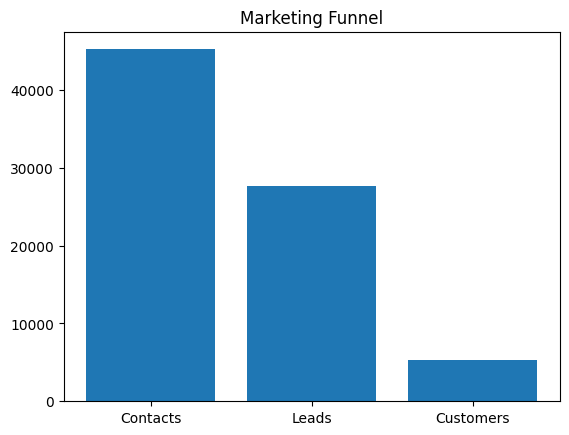

In [9]:
stages = ['Contacts', 'Leads', 'Customers']
values = [total_contacts, leads, customers]

plt.bar(stages, values)
plt.title("Marketing Funnel")
plt.show()

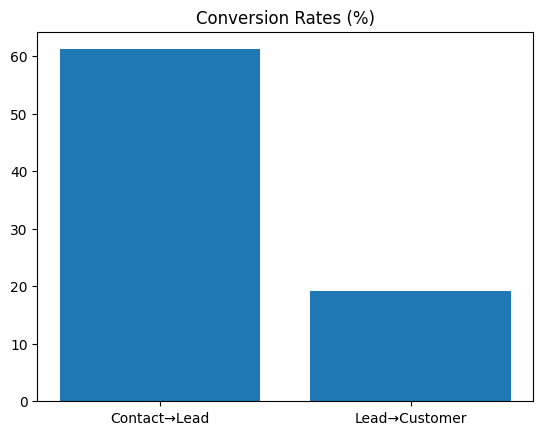

In [10]:
rates = [contact_to_lead, lead_to_customer]
labels = ['Contact→Lead', 'Lead→Customer']

plt.bar(labels, rates)
plt.title("Conversion Rates (%)")
plt.show()

In [11]:
job_perf = df.groupby('job')['y'].value_counts().unstack().fillna(0)

job_perf['conversion_rate'] = (job_perf['yes'] / (job_perf['yes'] + job_perf['no'])) * 100

job_perf.sort_values(by='conversion_rate', ascending=False)

y,no,yes,conversion_rate
job,,,
student,669,269,28.678038
retired,1748,516,22.791519
unemployed,1101,202,15.502686
management,8157,1301,13.755551
admin.,4540,631,12.202669
self-employed,1392,187,11.842939
unknown,254,34,11.805556
technician,6757,840,11.056996
services,3785,369,8.883004


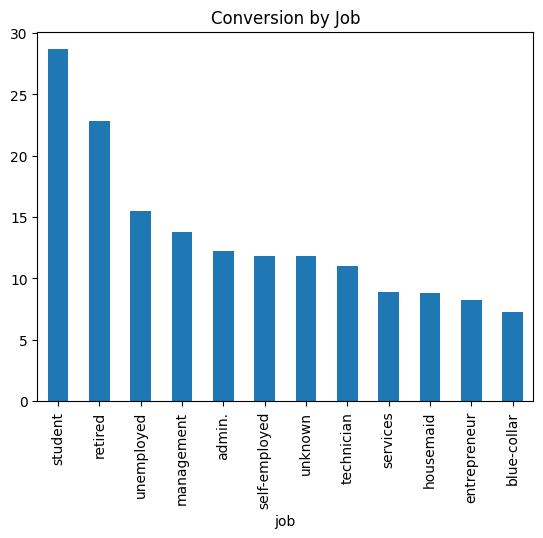

In [12]:
job_perf['conversion_rate'].sort_values(ascending=False).plot(kind='bar')
plt.title("Conversion by Job")
plt.show()

In [13]:
contact_perf = df.groupby('contact')['y'].value_counts().unstack().fillna(0)

contact_perf['conversion_rate'] = (contact_perf['yes'] / (contact_perf['yes'] + contact_perf['no'])) * 100

contact_perf

y,no,yes,conversion_rate
contact,,,
cellular,24916,4369,14.918900
telephone,2516,390,13.420509
unknown,12490,530,4.070661


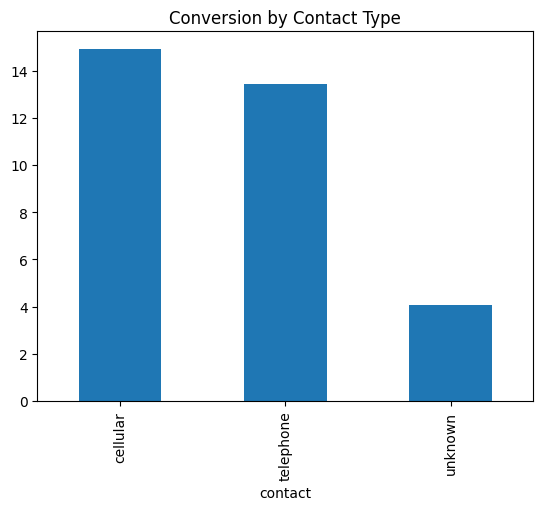

In [14]:
contact_perf['conversion_rate'].plot(kind='bar')
plt.title("Conversion by Contact Type")
plt.show()

In [15]:
month_perf = df.groupby('month')['y'].value_counts().unstack().fillna(0)

month_perf['conversion_rate'] = (month_perf['yes'] / (month_perf['yes'] + month_perf['no'])) * 100

month_perf.sort_values(by='conversion_rate', ascending=False)

y,no,yes,conversion_rate
month,,,
mar,229,248,51.991614
dec,114,100,46.728972
sep,310,269,46.459413
oct,415,323,43.766938
apr,2355,577,19.679400
feb,2208,441,16.647792
aug,5559,688,11.013286
jun,4795,546,10.222805
nov,3567,403,10.151134


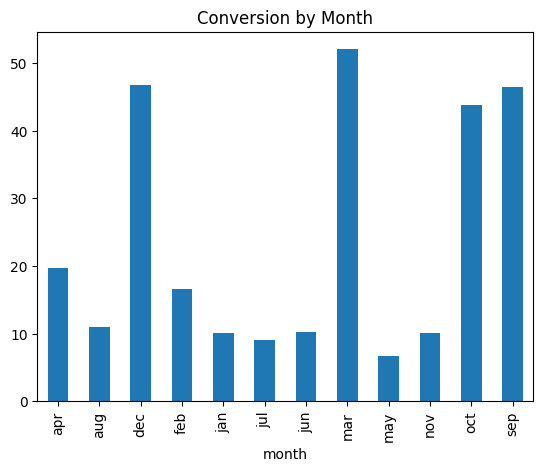

In [16]:
month_perf['conversion_rate'].plot(kind='bar')
plt.title("Conversion by Month")
plt.show()

## Key Insights

- High drop-off observed from contacts to customers
- Conversion rates are relatively low
- Certain job categories have higher conversions
- Contact method impacts success
- Some months perform better than others
  ## Recommendations

- Focus on high-converting job segments
- Improve targeting strategy
- Use best-performing contact method
- Optimize campaign timing (months)
- Reduce unnecessary repeated contacts